## A MACHINE LEARNING MODEL TO PREDICT TEAK TREE GROWTH IN FORM GHANA TEAK PLANTATIONS

#### Importing the relevant libraries

In [1]:
# PostgreSQL connection libraries
import psycopg2 
from sqlalchemy import create_engine

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re


#### Query Database to extract relevant data

In [2]:
# postgres connection parameters
DB_USER = "postgres"
DB_PASSWORD = "gogilbert9812806"
DB_NAME = "psp_db"
DB_HOST = "localhost"
DB_PORT = "5432"

conn_str = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(conn_str)

query = """
    SELECT 
        b.plantation,
        p.block,
        b."year planted",
        b."block area (ha)",
        p.plot,
        pmh."Default plot size",
        pmh."Plot type",
        d.area_type,
        d."monitoring year",
        d.tree_id,
        d."Tree SPECIES",
        d.height_m,
        d.dbh_cm,
        d.remarks
    FROM block_register b
    JOIN plot_block_relation p 
        ON b.plantation = p.plantation
        AND b.block = p.block
    JOIN plot_monitoring_history pmh
        ON pmh.plantation = p.plantation
        AND pmh.plot = p.plot
    JOIN treedata d 
        ON b.plantation = d.plantation
        AND d.plot = p.plot
        AND d.area_type = 'Teak';
"""

df = pd.read_sql_query(query, engine)

df.head()


,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars


### Data Exploration and Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8577780 entries, 0 to 8577779
Data columns (total 14 columns):
 #   Column             Dtype  
---  ------             -----  
 0   plantation         object 
 1   block              object 
 2   year planted       int64  
 3   block area (ha)    float64
 4   plot               object 
 5   Default plot size  float64
 6   Plot type          object 
 7   area_type          object 
 8   monitoring year    float64
 9   tree_id            float64
 10  Tree SPECIES       object 
 11  height_m           float64
 12  dbh_cm             float64
 13  remarks            object 
dtypes: float64(6), int64(1), object(7)
memory usage: 916.2+ MB


In [4]:
df.shape

(8577780, 14)

##### Check for Null values in Height and DBH

In [5]:
df[['height_m', 'dbh_cm']].isna().sum()

height_m     4788
dbh_cm      11404
dtype: int64

##### Drop all Null values in Height and DBH

In [6]:
df = df.dropna(subset=['height_m', 'dbh_cm'])

In [7]:
df.isna().sum()

plantation                 0
block                      0
year planted               0
block area (ha)            0
plot                       0
Default plot size          0
Plot type                  0
area_type                  0
monitoring year            0
tree_id                    0
Tree SPECIES            1468
height_m                   0
dbh_cm                     0
remarks              5778388
dtype: int64

In [8]:
# Review the remarks to check for unwanted data
df['remarks'].unique()

array(['Fire scars', None, 'Beetle infestation', 'Top broken', 'Coppice',
       'Broken top', 'Forked', 'Dead tree', 'Forked at 30 cm',
       'Fork at 2m', 'Nearly dead', '2 stems', 'Beside a termite mould',
       'leaves eaten by grasshoppers', 'Wildling',
       'Outside planting line - Wildling', 'marked',
       'bark damaged by termites', 'Dead tree - marked',
       'Has leaves to about 6m', 'dead tree, but resprouting',
       'Sapling - Wildling', 'Black ant attack from base to top',
       'dead tree, but coppicing', 'Old teak stand', 'Double stem',
       '3 stems', 'The tree is highly branched at this height sideways',
       'Dying', 'ceber', 'Main tree dead', 'Top dead', '', 'Beaten-up',
       'Taken with metre tape', 'DBH taken with metre tape',
       'Forked at DBH, taken above', 'No leaves, but alive',
       'Taken with metre tape.', 'Diseased', 'top slashed',
       'Teak dieback', 'Dbh taken with metre tape', 'Top dead - Wildling',
       'Circumference', 'Beate

In [9]:
unwanted = r"(Wildling|Coppice|Broken top|diseased|dead|Top broken|coppice|wildling|fork|Beetle|Old|dieback|die back|Dying|Diseased|Broken|Abnormal|crooked|marked)"

mask = df['remarks'].str.contains(unwanted, case=False, na=False)
df = df[~mask]

C:\Users\GILBERT FG\AppData\Local\Temp\ipykernel_9184\1056689533.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['remarks'].str.contains(unwanted, case=False, na=False)


In [10]:
df['remarks'].unique()

array(['Fire scars', None, '2 stems', 'Beside a termite mould',
       'leaves eaten by grasshoppers', 'bark damaged by termites',
       'Has leaves to about 6m', 'Black ant attack from base to top',
       'Double stem', '3 stems',
       'The tree is highly branched at this height sideways', 'ceber', '',
       'Beaten-up', 'Taken with metre tape', 'DBH taken with metre tape',
       'No leaves, but alive', 'Taken with metre tape.', 'top slashed',
       'Dbh taken with metre tape', 'Circumference',
       'Beaten-up. Top slashed', 'Sunto', 'sunto', '2012 teak',
       '2012 teak, top slashed', '2012 burnt teak', 'already planted',
       'Diameter taken with diameter tape', 'Tape',
       'Hole in it. Diameter taken with diameter tape',
       'Measured with diameter tape. Diameter taken with diameter tape',
       'Diameter < 0. Diameter taken with diameter tape',
       'diseasesed - Diameter taken with diameter tape',
       'No DHB entered. Diameter taken with diameter tape. DB

In [11]:
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars


In [12]:
# Check for any unwanted tree species in the data
df['Tree SPECIES'].unique()

array(['Teak', 'York', 'onyono', 'Mahogany', None, 'Albizia',
       'Awiemfosamina', 'Kyenkyen', 'Sofo', 'Onyina', 'Cassia', 'Wawa',
       'Unknown indigenous', 'Asanfena', 'Hontan', 'Akuakuo-Ninsuo',
       'Okoro', 'Nyankyerene', 'Watapuo', 'Akonkodie', 'Mango',
       'kwakuanisuo', 'Hyedua', 'Nyamedua', 'kotrenfro', 'Ofram',
       'Konkroma', 'Cedrela', 'Khaya ivorensis', 'Albizia adianthifolia',
       'Kane', 'Wama', 'Wonton', 'Odum', 'Trilepisium madagascariense',
       'Tetrapleura tetraptera', 'Kusia', 'Okure', 'Foto', 'Womba',
       'Alstonia boonei', 'Anacardium occidentale', 'Afzelia', 'Otie',
       'coconisuol', 'prekese', 'Kotreamfo', 'Acacia', 'Akye', 'Nofotene',
       'Acasia', 'Kigelia africana', 'Prekese', 'Kookonisuo'],
      dtype=object)

In [13]:
# Remove any wanted tree species and leave teak species
df = df[(df['Tree SPECIES'].str.lower() == 'teak')]

In [14]:
df['Tree SPECIES'].unique()

array(['Teak'], dtype=object)

In [15]:
df.shape

(8038356, 14)

In [16]:
# Describing the data
df[['height_m', 'dbh_cm']].describe()

,height_m,dbh_cm
count,8.038356e+06,8.038356e+06
mean,9.499586e+00,1.164350e+01
std,4.918124e+00,6.937685e+00
min,0.000000e+00,0.000000e+00
25%,5.770000e+00,6.250000e+00
50%,1.000000e+01,1.180000e+01
75%,1.325000e+01,1.660000e+01
max,3.725000e+01,5.270000e+01


In [24]:
# check for abnormality in the data
df['hd_ratio'] = (df['height_m'] / df['dbh_cm']) * 100

In [25]:
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667


In [28]:
# check for trees with h/d ratio of less than 30
hd_less_30 = df[(df['hd_ratio'] < 30)]

hd_less_30.count()

plantation           3292
block                3292
year planted         3292
block area (ha)      3292
plot                 3292
Default plot size    3292
Plot type            3292
area_type            3292
monitoring year      3292
tree_id              3292
Tree SPECIES         3292
height_m             3292
dbh_cm               3292
remarks               240
hd_ratio             3292
dtype: int64

In [29]:
# Describe data by plantation
df.groupby('plantation')[['height_m', 'dbh_cm']].describe()


height_m                                                     \
                count      mean       std  min   25%    50%   75%    max   
plantation                                                                 
Akumadan    4645524.0  9.522846  5.429569  0.0  5.25  10.40  13.5  37.25   
Tain II     3392832.0  9.467739  4.115813  0.0  6.25   9.25  12.8  22.35   

               dbh_cm                                                   
                count       mean       std  min  25%   50%   75%   max  
plantation                                                              
Akumadan    4645524.0  11.834355  7.759274  0.0  5.2  12.6  17.4  52.7  
Tain II     3392832.0  11.382183  5.610723  0.0  7.0  11.0  15.4  37.3

In [30]:
# Describe data by monitoring year
df.groupby(['plantation','monitoring year'])[['height_m', 'dbh_cm']].describe()

height_m                                     \
                               count       mean       std    min    25%   
plantation monitoring year                                                
Akumadan   2009.0            13180.0   6.006270  6.788701   0.12   0.83   
           2010.0            53608.0   1.495772  3.176836   0.00   0.22   
           2011.0           102892.0   1.980769  2.724228   0.01   0.30   
           2012.0           679516.0   1.967372  2.298219   0.00   0.40   
           2013.0           240660.0   5.316068  3.691108   0.02   3.00   
           2014.0           374180.0   5.753598  3.260973   0.14   3.70   
           2015.0           346472.0   7.686698  3.351902   0.05   5.80   
           2016.0             6348.0  20.710933  1.792941  14.25  19.50   
           2017.0           621240.0  10.656691  2.647001   1.50   9.00   
           2018.0           422736.0  11.025952  2.702820   2.00   9.50   
           2019.0           367724.0  11.958057  2.696761   3.50  10.50   
           2020.0           234404.0  13.397042  2.908034   4.25  11.50   
           2021.0           479224.0  13.897154  2.654321   3.25  12.50   
           2022.0           233176.0  14.565948  2.468324   5.50  13.00   
           2023.0           349488.0  15.702326  2.058934   5.75  14.50   
           2024.0           120676.0  16.147209  2.747934   4.00  14.50   
Tain II    2018.0           600908.0   5.640745  2.272224   0.00   4.00   
           2019.0           548492.0   7.499572  2.601209   0.15   5.75   
           2020.0           403524.0   7.590809  2.680986   0.65   5.75   
           2021.0           677688.0  10.682731  3.708242   0.30   8.25   
           2022.0           257076.0  10.454151  4.024823   0.25   8.00   
           2023.0           649800.0  12.476073  3.408704   0.10  10.50   
           2024.0           255344.0  13.794437  3.109035   0.20  12.50   

                                                   dbh_cm             \
                              50%    75%    max     count       mean   
plantation monitoring year                                             
Akumadan   2009.0            2.00  14.50  17.00   13180.0   5.794737   
           2010.0            0.42   1.15  18.30   53608.0   1.855514   
           2011.0            0.82   2.85  17.50  102892.0   1.733097   
           2012.0            0.94   2.80  20.50  679516.0   1.715319   
           2013.0            4.81   6.48  22.50  240660.0   5.524321   
           2014.0            5.40   7.30  32.00  374180.0   6.113817   
           2015.0            7.50   9.30  27.00  346472.0   8.547546   
           2016.0           21.00  22.00  25.50    6348.0  26.384562   
           2017.0           10.75  12.00  27.00  621240.0  13.212004   
           2018.0           11.00  12.50  28.00  422736.0  14.754804   
           2019.0           12.00  13.25  27.00  367724.0  16.011279   
           2020.0           13.25  14.75  30.25  234404.0  17.142088   
           2021.0           14.00  15.25  28.25  479224.0  17.805166   
           2022.0           14.75  16.00  29.00  233176.0  18.279327   
           2023.0           16.00  17.00  30.00  349488.0  20.078200   
           2024.0           16.40  17.80  37.25  120676.0  21.112135   
Tain II    2018.0            5.75   7.25  13.50  600908.0   6.491934   
           2019.0            7.75   9.50  15.75  548492.0   8.323132   
           2020.0            7.50   9.50  18.80  403524.0   9.665105   
           2021.0           11.25  13.50  21.75  677688.0  12.494434   
           2022.0           11.00  13.25  21.00  257076.0  12.682047   
           2023.0           13.25  15.00  21.10  649800.0  15.785845   
           2024.0           14.25  15.75  22.35  255344.0  16.707995   

                                                                              \
                                 std    min        25%        50%        75%   
plantation monitoring year                  

<Axes: xlabel='dbh_cm', ylabel='height_m'>

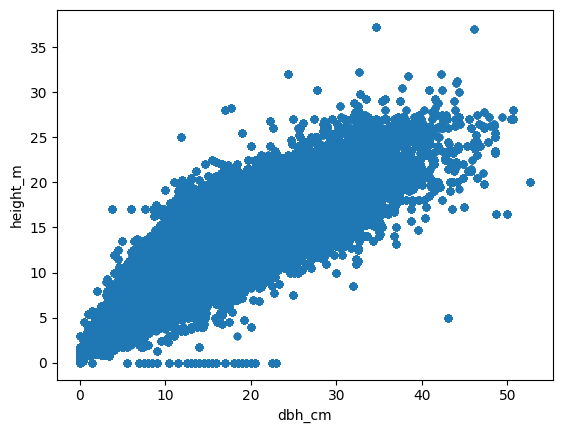

In [31]:
df.plot.scatter(x='dbh_cm', y='height_m')

In [32]:
# remove trees with hd ratio less than 30
df = df[~(df['hd_ratio'] < 30)]

In [33]:
df.shape

(8035064, 15)

<Axes: xlabel='dbh_cm', ylabel='height_m'>

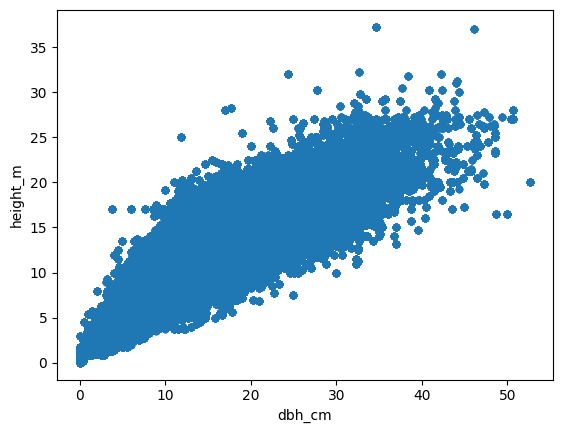

In [34]:
df.plot.scatter(x='dbh_cm', y='height_m')

<Axes: >

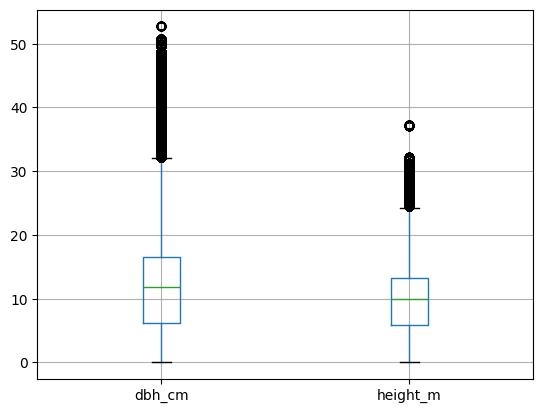

In [35]:
# check for outliers
df[['dbh_cm', 'height_m']].boxplot()

In [26]:
# Outliers in DBH
Q1_dbh = df['dbh_cm'].quantile(0.25)
Q3_dbh = df['dbh_cm'].quantile(0.75)
IQR_dbh = Q3_dbh - Q1_dbh

lower_dbh = Q1_dbh - 1.5  * IQR_dbh
upper_dbh = Q3_dbh + 1.5 * IQR_dbh

outliers_dbh = df[(df['dbh_cm'] < lower_dbh) | (df['dbh_cm'] > upper_dbh)]

outliers_dbh

,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio
1227940,Akumadan,1A,2001,65.694807,12,200.0,Circular,Teak,2013.0,30.0,Teak,21.5,34.0,None,63.235294
1227941,Akumadan,1A,2001,65.694807,12,200.0,Circular,Teak,2013.0,30.0,Teak,21.5,34.0,None,63.235294
1227942,Akumadan,1A,2001,65.694807,12,200.0,Circular,Teak,2013.0,30.0,Teak,21.5,34.0,None,63.235294
1227943,Akumadan,1A,2001,65.694807,12,200.0,Circular,Teak,2013.0,30.0,Teak,21.5,34.0,None,63.235294
1227944,Akumadan,1A,2001,65.694807,12,200.0,Circular,Teak,2013.0,30.0,Teak,21.5,34.0,None,63.235294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8577719,Akumadan,20A,2006,65.096183,450,800.0,Circular,Teak,2024.0,12.0,Teak,16.2,32.5,None,49.846154
8577720,Akumadan,20A,2006,65.096183,450,800.0,Circular,Teak,2024.0,12.0,Teak,16.2,32.5,None,49.846154
8577721,Akumadan,20A,2006,65.096183,450,800.0,Circular,Teak,2024.0,12.0,Teak,16.2,32.5,None,49.846154
8577722,Akumadan,20A,2006,65.096183,450,800.0,Circular,Teak,2024.0,12.0,Teak,16.2,32.5,None,49.846154


In [27]:
# Which year group does the dbh outliers found
outliers_dbh['year planted'].unique()

array([2001, 2006, 2011, 2012, 2009, 2022, 2010, 2013, 2008, 2015, 2017,
       2014])

In [29]:
# check the data below the quantile range
above_upper = df[df['dbh_cm'] > upper_dbh]
above_upper

,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio
1227940,Akumadan,1A,2001,65.694807,12,200.0,Circular,Teak,2013.0,30.0,Teak,21.5,34.0,None,63.235294
1227941,Akumadan,1A,2001,65.694807,12,200.0,Circular,Teak,2013.0,30.0,Teak,21.5,34.0,None,63.235294
1227942,Akumadan,1A,2001,65.694807,12,200.0,Circular,Teak,2013.0,30.0,Teak,21.5,34.0,None,63.235294
1227943,Akumadan,1A,2001,65.694807,12,200.0,Circular,Teak,2013.0,30.0,Teak,21.5,34.0,None,63.235294
1227944,Akumadan,1A,2001,65.694807,12,200.0,Circular,Teak,2013.0,30.0,Teak,21.5,34.0,None,63.235294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8577719,Akumadan,20A,2006,65.096183,450,800.0,Circular,Teak,2024.0,12.0,Teak,16.2,32.5,None,49.846154
8577720,Akumadan,20A,2006,65.096183,450,800.0,Circular,Teak,2024.0,12.0,Teak,16.2,32.5,None,49.846154
8577721,Akumadan,20A,2006,65.096183,450,800.0,Circular,Teak,2024.0,12.0,Teak,16.2,32.5,None,49.846154
8577722,Akumadan,20A,2006,65.096183,450,800.0,Circular,Teak,2024.0,12.0,Teak,16.2,32.5,None,49.846154


In [30]:
df[['height_m', 'dbh_cm']].describe()

,height_m,dbh_cm
count,8.035064e+06,8.035064e+06
mean,9.503140e+00,1.164242e+01
std,4.915888e+00,6.937911e+00
min,0.000000e+00,0.000000e+00
25%,5.800000e+00,6.224226e+00
50%,1.000000e+01,1.180000e+01
75%,1.325000e+01,1.660000e+01
max,3.725000e+01,5.270000e+01


### Derived Features

##### Compute Tree Ages

In [31]:
df['tree_age'] = df['monitoring year'] - df['year planted']
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,tree_age
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0


#### Compute Basal Area (m2)

In [32]:
df['basal_area_m2'] = (np.pi * (df['dbh_cm']/100)**2)/4

In [33]:
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,tree_age,basal_area_m2
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131


#### Basal Area per Hectare

In [34]:
df['basal_area_ha'] = df['basal_area_m2'] / (df['Default plot size']/10000)

In [35]:
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,tree_age,basal_area_m2,basal_area_ha
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514


#### Compute Tree Volume

In [36]:
form_factor = 0.47 # This is estimated value

df['volume_m3'] = df['basal_area_m2'] * df['height_m'] * form_factor

In [37]:
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,tree_age,basal_area_m2,basal_area_ha,volume_m3
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514,0.038538
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514,0.038538
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514,0.038538
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514,0.038538
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514,0.038538


#### Basal Area per block per monitoring year

In [38]:
block_ba = df.groupby(['plantation', 'block', 'year planted' ,'monitoring year'])['basal_area_m2'].sum().reset_index(name="basal_area_blk")

In [39]:
block_ba.head()

,plantation,block,year planted,monitoring year,basal_area_blk
0,Akumadan,10,2009,2010.0,0.214769
1,Akumadan,10,2009,2011.0,9.224030
2,Akumadan,10,2009,2012.0,73.657631
3,Akumadan,10,2009,2013.0,37.686624
4,Akumadan,10,2009,2014.0,183.534554


#### Volume per plot

In [40]:
plot_volume = df.groupby(['plantation','block', 'year planted', 'monitoring year','plot'])['volume_m3'].sum().reset_index(name='volume per plot')

In [41]:
plot_volume.head()

,plantation,block,year planted,monitoring year,plot,volume per plot
0,Akumadan,10,2009,2010.0,41,0.031787
1,Akumadan,10,2009,2010.0,42,0.000000
2,Akumadan,10,2009,2010.0,56,0.000000
3,Akumadan,10,2009,2010.0,57,0.000000
4,Akumadan,10,2009,2010.0,58,0.000000


#### Volume per hectare

In [42]:
df['volume_per_ha'] = df['volume_m3'] / (df['Default plot size']/10000)

In [43]:
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio,tree_age,basal_area_m2,basal_area_ha,volume_m3,volume_per_ha
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514,0.038538,0.528641
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514,0.038538,0.528641
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514,0.038538,0.528641
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514,0.038538,0.528641
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667,5.0,0.01131,0.15514,0.038538,0.528641


#### Volume per Hectare per Block

In [47]:
stand_volume_per_ha = df.groupby(['plantation', 'monitoring year','block'])['volume_per_ha'].nunique().reset_index(name='volume_block_ha')
stand_volume_per_ha.head()

,plantation,monitoring year,block,volume_block_ha
0,Akumadan,2009.0,1A,138
1,Akumadan,2009.0,2A,173
2,Akumadan,2009.0,3A,41
3,Akumadan,2010.0,10,60
4,Akumadan,2010.0,11,1


#### Machine Learning Models

#### Predicting Tree Volume at age 20

In [73]:
# Trees counted per plot
trees_per_plot = df.groupby(['plantation', 'monitoring year', 'block', 'plot'])['tree_id'].count().reset_index(name="#trees")
trees_per_plot.head(10)

,plantation,monitoring year,block,plot,#trees
0,Akumadan,2009.0,1A,11,624
1,Akumadan,2009.0,1A,12,936
2,Akumadan,2009.0,1A,13,312
3,Akumadan,2009.0,1A,14,832
4,Akumadan,2009.0,1A,15,728
5,Akumadan,2009.0,1A,16,988
6,Akumadan,2009.0,2A,1,680
7,Akumadan,2009.0,2A,2,960
8,Akumadan,2009.0,2A,3,1720
9,Akumadan,2009.0,2A,4,1040


In [77]:
plot_info = df.groupby(['plantation', 'monitoring year', 'plot'], as_index=False).agg({'Default plot size': 'first'})
plot_info.head()

,plantation,monitoring year,plot,Default plot size
0,Akumadan,2009.0,1,200.0
1,Akumadan,2009.0,11,400.0
2,Akumadan,2009.0,12,200.0
3,Akumadan,2009.0,13,250.0
4,Akumadan,2009.0,14,200.0


In [78]:
trees_per_plot = trees_per_plot.merge(
    plot_info, 
    on=['plantation', 'monitoring year','plot'], 
    how='left',
    validate='many_to_one'
)
trees_per_plot.head()

,plantation,monitoring year,block,plot,#trees,Default plot size
0,Akumadan,2009.0,1A,11,624,400.0
1,Akumadan,2009.0,1A,12,936,200.0
2,Akumadan,2009.0,1A,13,312,250.0
3,Akumadan,2009.0,1A,14,832,200.0
4,Akumadan,2009.0,1A,15,728,200.0


In [86]:
tph_block = (
    trees_per_plot.groupby(['plantation', 'block', 'monitoring year'])
    .agg(
        total_trees=("#trees", "sum"),
        total_area=("Default plot size", "sum")
    ).reset_index()
)

tph_block['tph'] = (tph_block["total_trees"] * 10000) / tph_block['total_area']

tph_block.head()

,plantation,block,monitoring year,total_trees,total_area,tph
0,Akumadan,10,2010.0,9688,2900.0,33406.896552
1,Akumadan,10,2011.0,7336,2000.0,36680.000000
2,Akumadan,10,2012.0,29584,2500.0,118336.000000
3,Akumadan,10,2013.0,6664,600.0,111066.666667
4,Akumadan,10,2014.0,25220,2300.0,109652.173913


In [87]:
tph_bkm = tph_block[(tph_block['plantation'] == 'Tain II')]
tph_bkm.head()

,plantation,block,monitoring year,total_trees,total_area,tph
427,Tain II,A19,2022.0,3696,7290.0,5069.958848
428,Tain II,A19,2023.0,3728,7290.0,5113.854595
429,Tain II,A20,2022.0,4312,7290.0,5914.951989
430,Tain II,A20,2023.0,4472,7290.0,6134.430727
431,Tain II,A21,2022.0,3248,5832.0,5569.272977


#### Predicting Stand Volume per hectare at age 20